<a href="https://colab.research.google.com/github/yashvi-raghuvanshi/Motionext/blob/main/GRU2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
video_dir = "/content/drive/MyDrive/Project/Attention/YouTubeClips"

In [ ]:
import os

videos = os.listdir(video_dir)
# print(videos)

In [ ]:
video_path = os.path.join(video_dir, videos[0])
print(video_path)

/content/drive/MyDrive/Project/Attention/YouTubeClips/IhwPQL9dFYc_137_143.avi


In [ ]:
import os
import cv2
import random
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import functools, operator
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.applications.inception_v3 import InceptionV3

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Project/Attention/data.csv")

df.head()

,VideoID,Description
0,-4wsuPCjDBc_5_15,a squirrel is eating a peanut in it s shell
1,-4wsuPCjDBc_5_15,a chipmunk is eating
2,-4wsuPCjDBc_5_15,a chipmunk is eating a peanut
3,-4wsuPCjDBc_5_15,a chipmunk is eating a nut
4,-4wsuPCjDBc_5_15,a squirrel is eating a nut


In [ ]:
videoIDs = list(df.VideoID.unique())
print(len(videoIDs))

1970


In [ ]:
def extract_frames_equally_spaced(frames, K):
    n_frames = len(frames)
    splits = np.array_split(range(n_frames), K)
    idx_taken = [s[0] for s in splits]
    return [frames[idx] for idx in idx_taken]


def pad_frames(frames, limit, jpegs=False):
    last_frame = frames[-1]
    if jpegs:
        frames_padded = frames + [last_frame] * (limit - len(frames))
    else:
        padding = np.asarray([last_frame * 0.] * (limit - len(frames)))
        frames_padded = np.concatenate([frames, padding], axis=0)
    return frames_padded


def video_to_frames(input_loc, K, motion=False):
    cap = cv2.VideoCapture(input_loc)
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)

    if len(frames) == 0:
      raise ValueError(f"No frames read from {input_loc}")

    cap.release()

    if motion:
        K = min(len(frames), 50)

    if len(frames) < K:
        frames = pad_frames(frames, K, True)
    else:
        frames = extract_frames_equally_spaced(frames, K)

    return frames


def resize_frames(frames, size=(224, 224)):
    return [cv2.resize(frame, size) for frame in frames]


K=28

In [ ]:
def get_model():
    i = tf.keras.layers.Input([224, 224, 3], dtype=tf.float32)
    x = tf.keras.applications.inception_v3.preprocess_input(i)
    model = InceptionV3(weights="imagenet", include_top=False, input_shape=(224, 224, 3), pooling='avg')
    out = model(x)
    model = tf.keras.models.Model(inputs=[i], outputs=out)
    return model

inception_model = get_model()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
inception_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 2048)           │    21,802,784 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 21,768,352 (83.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [66]:
def extract_global_features(model, save_every=200):
    feature_dir = '/content/drive/MyDrive/Project/Attention/global_features'
    os.makedirs(feature_dir, exist_ok
                =True)

    failed_ids = []
    processed_count = 0

    for index, id in enumerate(videoIDs):
        feature_path = os.path.join(feature_dir, id + '.npy')
        if os.path.exists(feature_path):
            continue

        path = '/content/drive/MyDrive/Project/Attention/YouTubeClips/' + id + '.avi'

        if not os.path.exists(path):
            print(index, ':', id, '-- FILE NOT FOUND')
            failed_ids.append(id)
            continue

        try:
            frames = video_to_frames(path, K)
            frames = resize_frames(frames)
            frames = np.array(frames)

            feature_vector = model.predict(frames, batch_size=128, verbose=0)
            np.save(feature_path, feature_vector)   # written directly to drive

            processed_count += 1
            print(index, ':', id)
        except Exception as e:
            print(index, ':', id, '-- FAILED:', str(e))
            failed_ids.append(id)
            continue

        if processed_count > 0 and processed_count % save_every == 0:
            print(f"--- {processed_count} processed so far ---")

    print("--- run complete ---")
    print(f"--- {len(failed_ids)} videos failed ---")

    if failed_ids:
        with open('/content/drive/MyDrive/Project/Attention/failed_ids.txt', 'w') as f:
            f.write('\n'.join(failed_ids))

    return failed_ids

In [67]:
extract_global_features(inception_model, save_every=200)

2 : -8y1Q0rA3n8_108_115 -- FILE NOT FOUND
3 : -8y1Q0rA3n8_95_102 -- FILE NOT FOUND
4 : -9CUm-2cui8_39_44 -- FILE NOT FOUND
6 : -Cv5LsqKUXc_17_25 -- FILE NOT FOUND
15 : -_hbPLsZvvo_18_25 -- FILE NOT FOUND
17 : -_hbPLsZvvo_19_26 -- FILE NOT FOUND
18 : -_hbPLsZvvo_211_219 -- FILE NOT FOUND
19 : -_hbPLsZvvo_269_275 -- FILE NOT FOUND
20 : -_hbPLsZvvo_288_305 -- FILE NOT FOUND
22 : -_hbPLsZvvo_43_55 -- FILE NOT FOUND
25 : -bjOB4zS0uE_100_105 -- FILE NOT FOUND
27 : -joBOHlg5J0_72_80 -- FILE NOT FOUND
34 : -t-ZWaJeH-o_0_15 -- FILE NOT FOUND
36 : -vKO3uSG6Do_3_14 -- FILE NOT FOUND
51 : 05gNigkqfNU_11_23 -- FILE NOT FOUND
56 : 08pVpBq706k_175_212 -- FILE NOT FOUND
57 : 0GXq1An3yHI_22_35 -- FILE NOT FOUND
61 : 0NPtAv3_uVI_46_54 -- FILE NOT FOUND
63 : 0RWJEOScToE_414_421 -- FILE NOT FOUND
65 : 0bSz70pYAP0_5_15 -- FILE NOT FOUND
67 : 0hyZ__3YhZc_289_295 -- FILE NOT FOUND
69 : 0hyZ__3YhZc_341_348 -- FILE NOT FOUND
71 : 0hyZ__3YhZc_364_370 -- FILE NOT FOUND
72 : 0hyZ__3YhZc_380_384 -- FILE NOT FOUND


['-8y1Q0rA3n8_108_115',
 '-8y1Q0rA3n8_95_102',
 '-9CUm-2cui8_39_44',
 '-Cv5LsqKUXc_17_25',
 '-_hbPLsZvvo_18_25',
 '-_hbPLsZvvo_19_26',
 '-_hbPLsZvvo_211_219',
 '-_hbPLsZvvo_269_275',
 '-_hbPLsZvvo_288_305',
 '-_hbPLsZvvo_43_55',
 '-bjOB4zS0uE_100_105',
 '-joBOHlg5J0_72_80',
 '-t-ZWaJeH-o_0_15',
 '-vKO3uSG6Do_3_14',
 '05gNigkqfNU_11_23',
 '08pVpBq706k_175_212',
 '0GXq1An3yHI_22_35',
 '0NPtAv3_uVI_46_54',
 '0RWJEOScToE_414_421',
 '0bSz70pYAP0_5_15',
 '0hyZ__3YhZc_289_295',
 '0hyZ__3YhZc_341_348',
 '0hyZ__3YhZc_364_370',
 '0hyZ__3YhZc_380_384',
 '0hyZ__3YhZc_388_394',
 '0hyZ__3YhZc_410_417',
 '0hyZ__3YhZc_418_424',
 '0hyZ__3YhZc_485_490',
 '0hyZ__3YhZc_562_568',
 '0hyZ__3YhZc_575_580',
 '0hyZ__3YhZc_632_637',
 '0piwbTivpDg_10_40',
 '0vmoZEaN_-o_5_21',
 '0xx13BuvVmo_25_36',
 '1Dty_eGY9Ec_123_133',
 '1dfR0A_BXjw_401_408',
 '1dfR0A_BXjw_441_448',
 '1dfR0A_BXjw_524_532',
 '1dfR0A_BXjw_545_560',
 '1dfR0A_BXjw_590_600',
 '1qxMJLkHDLw_0_9',
 '1sffYOXq4Iw_23_49',
 '21uB8g-jDZI_70_79',
 '2F9jX7u5n

In [68]:
!git clone https://github.com/adamcasson/c3d.git c3d_repo
!cp c3d_repo/c3d.py .
!cp c3d_repo/sports1M_utils.py .


fatal: destination path 'c3d_repo' already exists and is not an empty directory.


In [69]:
!sed -i \
  -e 's/from keras.utils.data_utils import get_file/from tensorflow.keras.utils import get_file/' \
  -e 's/from keras.layers.core import Dense, Dropout, Flatten/from tensorflow.keras.layers import Dense, Dropout, Flatten/' \
  -e 's/from keras.models import Sequential/from tensorflow.keras.models import Sequential/' \
  -e 's/import keras.backend as K/import tensorflow.keras.backend as K/' \
  -e 's/from keras.layers.convolutional import Conv3D, MaxPooling3D, ZeroPadding3D/from tensorflow.keras.layers import Conv3D, MaxPooling3D, ZeroPadding3D/' \
  /content/c3d.py

In [70]:
!sed -i \
  -e 's/from scipy.misc import imresize/import cv2/' \
  -e 's/from keras.utils.data_utils import get_file/from tensorflow.keras.utils import get_file/' \
  /content/sports1M_utils.py

In [71]:
!sed -i "s/img = imresize(img, (128,171), 'bicubic')/img = cv2.resize(img, (171, 128))/" /content/sports1M_utils.py

In [72]:
!pip install scikit-video

Exception ignored in: <function Meteor.__del__ at 0x7f3f9d3804a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/pycocoevalcap/meteor/meteor.py", line 78, in __del__
    self.lock.acquire()
KeyboardInterrupt: 
Exception ignored in: <function Meteor.__del__ at 0x7f3f9d3804a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/pycocoevalcap/meteor/meteor.py", line 78, in __del__
    self.lock.acquire()
KeyboardInterrupt: 


In [73]:
import importlib
import sports1M_utils

importlib.reload(sports1M_utils)

<module 'sports1M_utils' from '/content/sports1M_utils.py'>

In [74]:
import tensorflow as tf
from c3d import C3D
from tensorflow.keras.models import Model

def build_c3d_fc6_model():
    base_model = C3D(weights='sports1M')


    inp = tf.keras.Input(shape=(16, 112, 112, 3))
    x = inp
    for layer in base_model.layers:
        x = layer(x)
        if layer.name == 'fc6':
            break

    return Model(inputs=inp, outputs=x)

In [75]:
import cv2
import numpy as np

def video_to_frames_raw(input_loc):
    cap = cv2.VideoCapture(input_loc)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    cap.release()

    if len(frames) == 0:
        raise ValueError(f"No frames read from {input_loc}")
    return frames

In [76]:
def get_c3d_clips(input_loc, num_clips=28, clip_len=16):
    frames = video_to_frames_raw(input_loc)

    if len(frames) < clip_len:
        frames = pad_frames(frames, clip_len, True)

    all_clips = [frames[i:i + clip_len] for i in range(len(frames) - clip_len + 1)]
    clips = extract_frames_equally_spaced(all_clips, min(num_clips, len(all_clips)))
    return clips

In [77]:
import os
import sports1M_utils

FEATURE_DIR_MOTION = '/content/drive/MyDrive/Project/Attention/motion_features'
VIDEO_DIR = '/content/drive/MyDrive/Project/Attention/YouTubeClips/'

def extract_motion_features(model, usable_ids, num_clips=28):
    os.makedirs(FEATURE_DIR_MOTION, exist_ok=True)
    failed_ids = []
    processed_count = 0

    for index, id in enumerate(usable_ids):
        feature_path = os.path.join(FEATURE_DIR_MOTION, id + '.npy')
        if os.path.exists(feature_path):
            continue

        path = VIDEO_DIR + id + '.avi'

        try:
            clips = get_c3d_clips(path, num_clips=num_clips, clip_len=16)

            batch = np.concatenate(
                [sports1M_utils.preprocess_input(np.array(clip)) for clip in clips],
                axis=0
            )
            motion_features_video = model.predict(batch, batch_size=8, verbose=0)

            np.save(feature_path, motion_features_video)
            processed_count += 1
            print(index, ':', id, '->', motion_features_video.shape)

        except Exception as e:
            print(index, ':', id, '-- FAILED:', str(e))
            failed_ids.append(id)
            continue

        if processed_count > 0 and processed_count % 200 == 0:
            print(f"--- {processed_count} processed so far ---")

    print("--- run complete ---")
    print(f"--- {len(failed_ids)} videos failed ---")

    if failed_ids:
        with open('/content/drive/MyDrive/Project/Attention/failed_motion_ids.txt', 'w') as f:
            f.write('\n'.join(failed_ids))

    return failed_ids

In [78]:
c3d_model = build_c3d_fc6_model()

In [81]:
FEATURE_DIR_GLOBAL = '/content/drive/MyDrive/Project/Attention/global_features'
existing_features = set(f.replace('.npy', '') for f in os.listdir(FEATURE_DIR_GLOBAL))

bad_ids = ['TPD5wO_LEPU_2_6']

usable_ids = sorted([id for id in videoIDs if id in existing_features and id not in bad_ids])
print(len(usable_ids))
print('TPD5wO_LEPU_2_6' in usable_ids)

1448
False


In [79]:
failed = extract_motion_features(c3d_model, usable_ids)

--- run complete ---
--- 0 videos failed ---


In [80]:
FEATURE_DIR_GLOBAL = '/content/drive/MyDrive/Project/Attention/global_features'
FEATURE_DIR_MOTION = '/content/drive/MyDrive/Project/Attention/motion_features'

In [82]:
x_data_global = {}
for id in usable_ids:
    feat_path = os.path.join(FEATURE_DIR_GLOBAL, id + '.npy')
    x_data_global[id] = np.load(feat_path)
print(len(x_data_global))

1448


In [83]:
x_data_motion = {}
for id in usable_ids:
    feat_path = os.path.join(FEATURE_DIR_MOTION, id + '.npy')
    x_data_motion[id] = np.load(feat_path)
print(len(x_data_motion))

KeyboardInterrupt: 

In [ ]:
# split data into training and testing and validation
import json

split_path = '/content/drive/MyDrive/Project/Attention/data_split_v3.json'

if os.path.exists(split_path):
    with open(split_path) as f:
        split = json.load(f)
    train_video_ids = split['train']
    val_video_ids = split['val']
    test_ids = split['test']
else:
    usable_ids_sorted = sorted(usable_ids)
    random.seed(42)
    shuffled_ids = usable_ids_sorted.copy()
    random.shuffle(shuffled_ids)

    test_ids = shuffled_ids[:200]
    val_video_ids = shuffled_ids[200:400]
    train_video_ids = shuffled_ids[400:]

    with open(split_path, 'w') as f:
        json.dump({'train': train_video_ids, 'val': val_video_ids, 'test': test_ids}, f)

print(len(train_video_ids), len(val_video_ids), len(test_ids))

In [ ]:
import os
print(os.path.exists('/content/drive/MyDrive/Project/Attention/data_split_v3.json'))

In [ ]:
# os.remove('/content/drive/MyDrive/Project/Attention/data_split_v3.json')

# random.seed(42)
# shuffled_ids = usable_ids.copy()
# random.shuffle(shuffled_ids)

# test_ids = shuffled_ids[:200]
# val_video_ids = shuffled_ids[200:400]
# train_video_ids = shuffled_ids[400:]

# print(len(train_video_ids), len(val_video_ids), len(test_ids))

# import json
# with open('/content/drive/MyDrive/Project/Attention/data_split_v3.json', 'w') as f:
#     json.dump({'train': train_video_ids, 'val': val_video_ids, 'test': test_ids}, f)

1048 200 200


In [ ]:
import json

split_path = '/content/drive/MyDrive/Project/Attention/data_split_v3.json'

with open(split_path) as f:
    split = json.load(f)

train_video_ids = split['train']
val_video_ids = split['val']
test_ids = split['test']

print(len(train_video_ids), len(val_video_ids), len(test_ids))

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Project/Attention/data.csv')

def build_caption_list(video_ids):
    caption_list = []
    for vid in video_ids:
        df_temp = df.loc[df['VideoID'] == vid]
        for _, row in df_temp.iterrows():
            caption = "<bos> " + row['Description'] + " <eos>"
            if 6 <= len(caption.split()) <= 10:
                caption_list.append([caption, vid])
    return caption_list

training_list = build_caption_list(train_video_ids)
validation_list = build_caption_list(val_video_ids)

vocab_list = [pair[0] for pair in training_list]
tokenizer = Tokenizer(num_words=1500)
tokenizer.fit_on_texts(vocab_list)

print(len(training_list), len(validation_list))

In [ ]:
import warnings
warnings.filterwarnings("ignore")
tf.get_logger().setLevel('ERROR')

# Hyperparameters
time_steps_encoder=28
num_encoder_tokens_global = 2048
num_encoder_tokens_motion = 4096
latent_dim=512
time_steps_decoder=10
num_decoder_tokens=1500
batch_size=320
epochs = 25
save_model_path = 'model_final'

In [ ]:
from tensorflow.keras import backend as K2


class attention(tf.keras.layers.Layer):
    def __init__(self, return_sequences=True, **kwargs):
        self.return_sequences = return_sequences
        super(attention, self).__init__()

    def get_config(self):
        config = super().get_config().copy()
        config.update({'return_sequences': self.return_sequences})
        return config

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(attention, self).build(input_shape)

    def call(self, x):
        e = K2.tanh(K2.dot(x, self.W) + self.b)
        a = K2.softmax(e, axis=1)
        output = x * a
        if self.return_sequences:
            return output
        return K2.sum(output, axis=1)

In [ ]:
def load_dataset(data_list):
    train_videoIDs = [cap[1] for cap in data_list]
    videoSeq = [cap[0] for cap in data_list]

    train_sequences = tokenizer.texts_to_sequences(videoSeq)
    train_sequences = pad_sequences(train_sequences, padding='post', truncating='post', maxlen=10)
    file_size = len(train_sequences)

    encoder_input_data_global, encoder_input_data_motion = [], []
    decoder_input_data, decoder_target_data, sample_weights = [], [], []
    n = 0

    while True:
        for idx in range(file_size):
            n += 1
            encoder_input_data_global.append(x_data_global[train_videoIDs[idx]])
            encoder_input_data_motion.append(x_data_motion[train_videoIDs[idx]])

            seq = train_sequences[idx]
            y_in = seq[:-1]                      # decoder input: integer indices
            y_out = seq[1:]                      # decoder target: integer indices
            mask = (y_out != 0).astype(np.float32)  # 1 for real words, 0 for padding

            decoder_input_data.append(tf.keras.utils.to_categorical(y_in, num_decoder_tokens))
            decoder_target_data.append(y_out)
            sample_weights.append(mask)

            if n == batch_size:
                out = ((np.array(encoder_input_data_global, dtype=np.float32),
                        np.array(encoder_input_data_motion, dtype=np.float32),
                        np.array(decoder_input_data, dtype=np.float32)),
                       np.array(decoder_target_data, dtype=np.int32),
                       np.array(sample_weights, dtype=np.float32))
                encoder_input_data_global, encoder_input_data_motion = [], []
                decoder_input_data, decoder_target_data, sample_weights = [], [], []
                n = 0
                yield out

In [ ]:
CHECKPOINT_DIR_V5 = '/content/drive/MyDrive/Project/Attention/model_checkpoints_v5'
SAVE_MODEL_DIR_V5 = '/content/drive/MyDrive/Project/Attention/model_final_v5'
HISTORY_DIR_V5 = '/content/drive/MyDrive/Project/Attention/history_logs_v5'

os.makedirs(CHECKPOINT_DIR_V5, exist_ok=True)
os.makedirs(SAVE_MODEL_DIR_V5, exist_ok=True)
os.makedirs(HISTORY_DIR_V5, exist_ok=True)

def train_model(resume=True):
    encoder_inputs_global = tf.keras.layers.Input(shape=(time_steps_encoder, num_encoder_tokens_global), name="encoder_inputs_global")
    encoder_inputs_motion = tf.keras.layers.Input(shape=(time_steps_encoder, num_encoder_tokens_motion), name="encoder_inputs_motion")
    encoder_inputs = tf.keras.layers.Concatenate(axis=2)([encoder_inputs_global, encoder_inputs_motion])

    encoder = tf.keras.layers.GRU(latent_dim, return_state=True, return_sequences=True, name='encoder_gru')
    encoder_seq_output, state_h = encoder(encoder_inputs)
    attention_output = attention(return_sequences=False)(encoder_seq_output)
    encoder_states = [attention_output]

    decoder_inputs = tf.keras.layers.Input(shape=(time_steps_decoder - 1, num_decoder_tokens), name="decoder_inputs")
    decoder_gru = tf.keras.layers.GRU(latent_dim, return_sequences=True, return_state=True, name='decoder_gru')
    decoder_outputs, _ = decoder_gru(decoder_inputs, initial_state=encoder_states)
    decoder_outputs = tf.keras.layers.Dropout(0.3)(decoder_outputs)
    decoder_dense = tf.keras.layers.Dense(num_decoder_tokens, activation='softmax', name='decoder_softmax')
    decoder_outputs = decoder_dense(decoder_outputs)

    model = tf.keras.models.Model([encoder_inputs_global, encoder_inputs_motion, decoder_inputs], decoder_outputs)
    opt = tf.keras.optimizers.Adam(learning_rate=0.0003)
    model.compile(metrics=['accuracy'], optimizer=opt, loss='sparse_categorical_crossentropy')  # CHANGED

    initial_epoch = 0
    if resume:
        ckpts = sorted([f for f in os.listdir(CHECKPOINT_DIR_V5) if f.startswith('ckpt_epoch') and f.endswith('.keras')])
        if ckpts:
            latest = ckpts[-1]
            model = tf.keras.models.load_model(os.path.join(CHECKPOINT_DIR_V5, latest), custom_objects={'attention': attention})
            initial_epoch = int(latest.split('epoch')[1].split('.')[0])
            print(f"Resuming from {latest}, starting at epoch {initial_epoch}")
        else:
            print("No checkpoint found, training from scratch")

    output_signature = (
        (
            tf.TensorSpec(shape=(None, time_steps_encoder, num_encoder_tokens_global), dtype=tf.float32),
            tf.TensorSpec(shape=(None, time_steps_encoder, num_encoder_tokens_motion), dtype=tf.float32),
            tf.TensorSpec(shape=(None, time_steps_decoder - 1, num_decoder_tokens), dtype=tf.float32),
        ),
        tf.TensorSpec(shape=(None, time_steps_decoder - 1), dtype=tf.int32),      # CHANGED: integer targets
        tf.TensorSpec(shape=(None, time_steps_decoder - 1), dtype=tf.float32)     # NEW: sample weights
    )

    train_ds = tf.data.Dataset.from_generator(lambda: load_dataset(training_list), output_signature=output_signature)
    valid_ds = tf.data.Dataset.from_generator(lambda: load_dataset(validation_list), output_signature=output_signature)

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.1, patience=5, verbose=1, mode="auto")
    checkpoint_epoch_cb = tf.keras.callbacks.ModelCheckpoint(
        os.path.join(CHECKPOINT_DIR_V5, 'ckpt_epoch{epoch:02d}.keras'),
        save_weights_only=False, save_freq='epoch', verbose=1
    )

    validation_steps = max(1, len(validation_list) // batch_size)
    steps_per_epoch = len(training_list) // batch_size

    history = model.fit(train_ds, validation_data=valid_ds, validation_steps=validation_steps,
                         epochs=epochs, steps_per_epoch=steps_per_epoch,
                         initial_epoch=initial_epoch,
                         callbacks=[reduce_lr, checkpoint_epoch_cb])

    import pickle
    if history.epoch:
        hist_path = os.path.join(HISTORY_DIR_V5, f'history_e{initial_epoch+1}_to_e{max(history.epoch)+1}.pkl')
        with open(hist_path, 'wb') as f:
            pickle.dump(history.history, f)
        print(f"History saved to {hist_path}")

    encoder_model = tf.keras.models.Model([encoder_inputs_global, encoder_inputs_motion], encoder_states)
    decoder_state_input_h = tf.keras.layers.Input(shape=(latent_dim,))
    dec_out, dec_state_h = decoder_gru(decoder_inputs, initial_state=[decoder_state_input_h])
    dec_out = decoder_dense(dec_out)
    decoder_model = tf.keras.models.Model([decoder_inputs, decoder_state_input_h], [dec_out, dec_state_h])

    encoder_model.save(os.path.join(SAVE_MODEL_DIR_V5, 'encoder_model.keras'))
    decoder_model.save_weights(os.path.join(SAVE_MODEL_DIR_V5, 'decoder_model.weights.h5'))
    with open(os.path.join(SAVE_MODEL_DIR_V5, 'tokenizer' + str(num_decoder_tokens)), 'wb') as file:
        joblib.dump(tokenizer, file)

    return history

In [ ]:
FEATURE_DIR_MOTION = '/content/drive/MyDrive/Project/Attention/motion_features'
bad_shapes = []

for id in usable_ids:
    arr = np.load(os.path.join(FEATURE_DIR_MOTION, id + '.npy'))
    if arr.shape != (28, 4096):
        bad_shapes.append((id, arr.shape))

print(len(bad_shapes), 'videos with unexpected motion shape')
print(bad_shapes[:10])

0 videos with unexpected motion shape
[]


In [65]:
epochs = 25
history = train_model(resume=True)

Epoch 1/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.1710 - loss: 3.8617
Epoch 1: saving model to /content/drive/MyDrive/Project/Attention/model_checkpoints_v5/ckpt_epoch01.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Project/Attention/model_checkpoints_v5/ckpt_epoch01.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 783s 8s/step - accuracy: 0.2178 - loss: 3.3849 - val_accuracy: 0.2622 - val_loss: 2.8097 - learning_rate: 3.0000e-04
Epoch 2/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.2687 - loss: 2.9232
Epoch 2: saving model to /content/drive/MyDrive/Project/Attention/model_checkpoints_v5/ckpt_epoch02.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Project/Attention/model_checkpoints_v5/ckpt_epoch02.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 801s 8s/step - accuracy: 0.2724 - loss: 2.8739 - val_accuracy: 0.2804 - val_loss: 2.6518 - learning_rate: 3.0000e-04
Epoch 3/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.2795 - loss: 2.7663
Epoch 3: saving mod

['history_e1_to_e25.pkl']


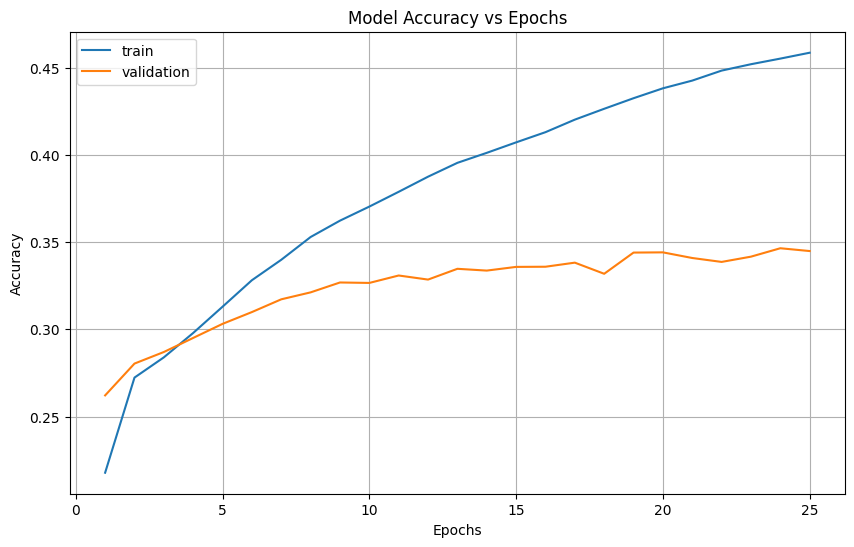

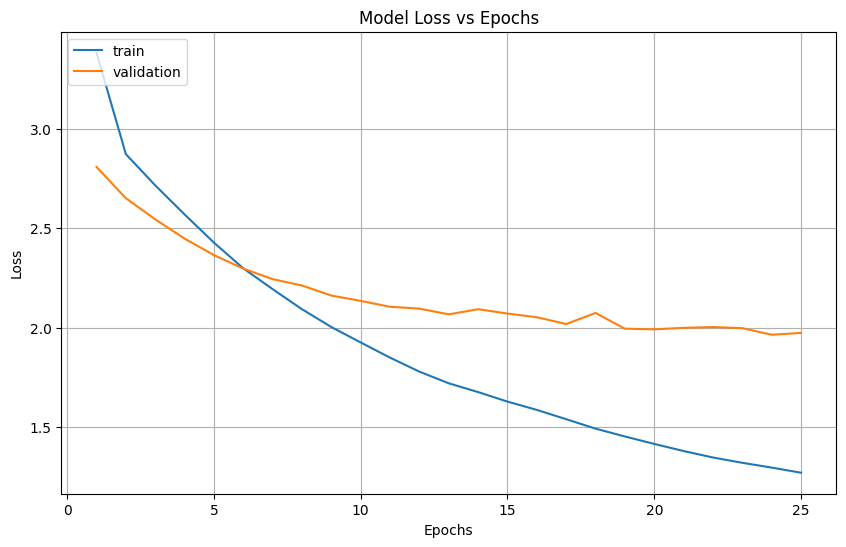

In [84]:
import pickle
import re
import matplotlib.pyplot as plt

HISTORY_DIR_V4 = '/content/drive/MyDrive/Project/Attention/history_logs_v5'

hist_files = os.listdir(HISTORY_DIR_V4)

def start_epoch(fname):
    match = re.search(r'history_e(\d+)_to_e(\d+)', fname)
    return int(match.group(1)) if match else 0

hist_files = sorted(hist_files, key=start_epoch)
print(hist_files)  # sanity check before plotting

combined = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
epoch_labels = []

for fname in hist_files:
    match = re.search(r'history_e(\d+)_to_e(\d+)', fname)
    start = int(match.group(1))

    with open(os.path.join(HISTORY_DIR_V4, fname), 'rb') as f:
        h = pickle.load(f)

    n = len(h['accuracy'])
    epoch_labels.extend(range(start, start + n))
    for key in combined:
        if key in h:
            combined[key].extend(h[key])

# Accuracy plot
plt.figure(figsize=(10, 6))
plt.grid(True)
plt.plot(epoch_labels, combined['accuracy'])
plt.plot(epoch_labels, combined['val_accuracy'])
plt.title('Model Accuracy vs Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# Loss plot
plt.figure(figsize=(10, 6))
plt.grid(True)
plt.plot(epoch_labels, combined['loss'])
plt.plot(epoch_labels, combined['val_loss'])
plt.title('Model Loss vs Epochs')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [88]:
print(os.path.exists('/content/drive/MyDrive/Project/Attention/model_final_v5/encoder_model.keras'))

True


In [112]:
class Video2Text(object):
    def __init__(self):
        self.latent_dim = 512
        self.num_encoder_tokens_global = 2048
        self.num_encoder_tokens_motion = 4096
        self.num_decoder_tokens = 1500
        self.time_steps_encoder = 28
        self.max_probability = -1

        self.tokenizer = None
        self.inf_encoder_model = None
        self.inf_decoder_model = None

        self.save_model_path = '/content/drive/MyDrive/Project/Attention/model_final_v5'
        self.test_path_global = '/content/drive/MyDrive/Project/Attention/global_features'
        self.test_path_motion = '/content/drive/MyDrive/Project/Attention/motion_features'

    def load_inference_models(self):
        with open(os.path.join(self.save_model_path, 'tokenizer' + str(self.num_decoder_tokens)), 'rb') as file:
            self.tokenizer = joblib.load(file)

        self.inf_encoder_model = tf.keras.models.load_model(
            os.path.join(self.save_model_path, 'encoder_model.keras'),
            custom_objects={'attention': attention}
        )

        decoder_inputs = tf.keras.layers.Input(shape=(None, self.num_decoder_tokens))
        decoder_dense = tf.keras.layers.Dense(self.num_decoder_tokens, activation='softmax')

        decoder_gru = tf.keras.layers.GRU(self.latent_dim, return_sequences=True, return_state=True)
        decoder_state_input_h = tf.keras.layers.Input(shape=(self.latent_dim,))
        decoder_outputs, state_h = decoder_gru(decoder_inputs, initial_state=[decoder_state_input_h])
        decoder_outputs = decoder_dense(decoder_outputs)
        self.inf_decoder_model = tf.keras.models.Model(
            [decoder_inputs, decoder_state_input_h],
            [decoder_outputs, state_h])

        self.inf_decoder_model.load_weights(os.path.join(self.save_model_path, 'decoder_model.weights.h5'))
        print('Loaded Inference Model')

    def index_to_word(self):
        return {value: key for key, value in self.tokenizer.word_index.items()}

    def greedy_search(self, f_global, f_motion):
        inv_map = self.index_to_word()

        states_value = self.inf_encoder_model.predict(
            [f_global.reshape(1, self.time_steps_encoder, self.num_encoder_tokens_global),
             f_motion.reshape(1, self.time_steps_encoder, self.num_encoder_tokens_motion)],
            verbose=0
        )
        states_value = np.array(states_value).reshape((1, self.latent_dim))

        target_seq = np.zeros((1, 1, self.num_decoder_tokens))
        target_seq[0, 0, self.tokenizer.word_index['bos']] = 1
        sentence = ''

        for i in range(15):
            output_tokens, h = self.inf_decoder_model.predict([target_seq, states_value], verbose=0)
            states_value = h
            output_tokens = output_tokens.reshape(self.num_decoder_tokens)
            y_hat = np.argmax(output_tokens)
            if y_hat == 0:
                continue
            word = inv_map.get(y_hat)
            if word is None or word == 'eos':
                break
            sentence += word + ' '
            target_seq = np.zeros((1, 1, self.num_decoder_tokens))
            target_seq[0, 0, y_hat] = 1

        return sentence.strip()

    def beam_search(self, f_global, f_motion, beam_width=3, max_len=10):
        inv_map = self.index_to_word()

        states_value = self.inf_encoder_model.predict(
            [f_global.reshape(1, self.time_steps_encoder, self.num_encoder_tokens_global),
             f_motion.reshape(1, self.time_steps_encoder, self.num_encoder_tokens_motion)],
            verbose=0
        )
        states_value = np.array(states_value).reshape((1, self.latent_dim))

        target_seq = np.zeros((1, 1, self.num_decoder_tokens))
        target_seq[0, 0, self.tokenizer.word_index['bos']] = 1

        # each beam: (sequence_of_word_indices, cumulative_log_prob, states, target_seq)
        beams = [([], 0.0, states_value, target_seq)]
        completed = []

        for step in range(max_len):
            candidates = []
            for seq, log_prob, state, t_seq in beams:
                output_tokens, h = self.inf_decoder_model.predict([t_seq, state], verbose=0)
                output_tokens = output_tokens.reshape(self.num_decoder_tokens)

                output_tokens = np.clip(output_tokens, 1e-10, 1.0)
                top_indices = np.argsort(output_tokens)[-beam_width:]

                for idx in top_indices:
                    if idx == 0:
                        continue
                    word = inv_map.get(idx)
                    new_log_prob = log_prob + np.log(output_tokens[idx])
                    new_seq = seq + [idx]

                    if word == 'eos':
                        completed.append((new_seq, new_log_prob))
                        continue

                    new_target_seq = np.zeros((1, 1, self.num_decoder_tokens))
                    new_target_seq[0, 0, idx] = 1
                    candidates.append((new_seq, new_log_prob, h, new_target_seq))

            if not candidates:
                break

            candidates.sort(key=lambda x: x[1], reverse=True)
            beams = candidates[:beam_width]

        if not completed:
            completed = [(seq, log_prob) for seq, log_prob, _, _ in beams]

        best_seq, best_score = max(completed, key=lambda x: x[1] / max(len(x[0]), 1))

        words = [inv_map.get(idx) for idx in best_seq if inv_map.get(idx) not in (None, 'eos')]
        return ' '.join(words)

    def get_test_data(self, test_ids):
        X_global, X_motion, X_filenames = [], [], []
        for filename in test_ids:
            g_path = os.path.join(self.test_path_global, filename + '.npy')
            m_path = os.path.join(self.test_path_motion, filename + '.npy')
            if not (os.path.exists(g_path) and os.path.exists(m_path)):
                print(f"Skipping {filename} -- missing feature file")
                continue
            X_global.append(np.load(g_path))
            X_motion.append(np.load(m_path))
            X_filenames.append(filename)
        return X_global, X_motion, X_filenames

    def test(self, test_ids):
        X_global, X_motion, X_filenames = self.get_test_data(test_ids)
        print(len(X_filenames), 'test videos (greedy)')

        output_path = os.path.join(self.save_model_path, 'test_output.txt')
        with open(output_path, 'w') as file:
            for idx in range(len(X_filenames)):
                sentence = self.greedy_search(X_global[idx], X_motion[idx])
                file.write(X_filenames[idx] + ',' + sentence + '\n')

        print("Greedy search output written to", output_path)

    def test_beam(self, test_ids, beam_width=3):
        X_global, X_motion, X_filenames = self.get_test_data(test_ids)
        print(len(X_filenames), 'test videos (beam search)')

        output_path = os.path.join(self.save_model_path, 'test_output_beam.txt')
        with open(output_path, 'w') as file:
            for idx in range(len(X_filenames)):
                sentence = self.beam_search(X_global[idx], X_motion[idx], beam_width=beam_width)
                file.write(X_filenames[idx] + ',' + sentence + '\n')

        print("Beam search output written to", output_path)

In [113]:
    def test_beam(self, test_ids, beam_width=3):
        X_global, X_motion, X_filenames = self.get_test_data(test_ids)
        print(len(X_filenames), 'test videos (beam search)')

        output_path = os.path.join(self.save_model_path, 'test_output_beam.txt')
        with open(output_path, 'w') as file:
            for idx in range(len(X_filenames)):
                sentence = self.beam_search(X_global[idx], X_motion[idx], beam_width=beam_width)
                file.write(X_filenames[idx] + ',' + sentence + '\n')

        print("Beam search output written to", output_path)

In [114]:
v2t = Video2Text()
v2t.load_inference_models()

v2t.test(test_ids)              # greedy -> test_output.txt
v2t.test_beam(test_ids, beam_width=3)   # beam -> test_output_beam.txt

Loaded Inference Model
200 test videos (greedy)
Greedy search output written to /content/drive/MyDrive/Project/Attention/model_final_v5/test_output.txt
200 test videos (beam search)
Beam search output written to /content/drive/MyDrive/Project/Attention/model_final_v5/test_output_beam.txt


In [116]:
print(f"{'Video ID':<25} {'Greedy':<45} {'Beam'}")
print("-" * 110)
for vid in test_ids[:20]:  # first 20, adjust as needed
    g = generated_dict_greedy.get(vid, 'MISSING')
    b = generated_dict_beam.get(vid, 'MISSING')
    print(f"{vid:<25} {g:<45} {b}")

Video ID                  Greedy                                        Beam
--------------------------------------------------------------------------------------------------------------
JsD6uEZsIsU_45_58         a man is playing a guitar                     a man is playing a guitar
c76tShLfQb0_74_81         a man is drinking                             a man is drinking
rw9h_574HxE_13_18         two men are playing                           two men are playing
e-sf-hyrkTs_20_35         a woman is playing a flute                    a woman is playing a flute
N3A7944_UJw_63_70         a person is cooking                           a person is cooking
hksxtbcS780_7_14          a panda is playing with a                     a panda is playing with the mirror
LSuVRWPoHr0_0_37          a person is cutting a piece of paper          a person is cutting a piece of paper
xxHx6s_DbUo_216_222       a man is walking down a tree                  a man is walking down a tree
3ftaoFnhTyY_140_150     

In [115]:
def build_hyp_dict(output_file, test_ids):
    generated_dict = {}
    with open(output_file) as f:
        for line in f:
            vid, caption = line.strip().split(',', 1)
            generated_dict[vid] = caption

    hyp_dict = {'annotations': []}
    missing = []
    for i, vid in enumerate(test_ids):
        caption = generated_dict.get(vid)
        if caption is None:
            missing.append(vid)
            caption = ''
        hyp_dict['annotations'].append({'video_id': i, 'caption': caption})

    print(len(hyp_dict['annotations']), 'captions matched from', output_file)
    if missing:
        print(f"WARNING: {len(missing)} missing:", missing[:5])

    return hyp_dict, generated_dict


# --- Greedy search results ---
print("=== GREEDY SEARCH ===")
hyp_dict_greedy, generated_dict_greedy = build_hyp_dict(
    '/content/drive/MyDrive/Project/Attention/model_final_v5/test_output.txt', test_ids
)
rng = range(len(test_ids))
scores_greedy = calculate_metrics(rng, ref_dict, hyp_dict_greedy)
print(scores_greedy)

print()

# --- Beam search results ---
print("=== BEAM SEARCH ===")
hyp_dict_beam, generated_dict_beam = build_hyp_dict(
    '/content/drive/MyDrive/Project/Attention/model_final_v5/test_output_beam.txt', test_ids
)
scores_beam = calculate_metrics(rng, ref_dict, hyp_dict_beam)
print(scores_beam)

=== GREEDY SEARCH ===
200 captions matched from /content/drive/MyDrive/Project/Attention/model_final_v5/test_output.txt
tokenization...
setting up scorers...
computing Bleu score...
{'testlen': 1122, 'reflen': 1123, 'guess': [1122, 922, 722, 522], 'correct': [698, 233, 98, 26]}
ratio: 0.9991095280489768
Bleu_1: 0.622
Bleu_2: 0.396
Bleu_3: 0.277
Bleu_4: 0.180
computing Rouge score...
ROUGE_L: 0.523
computing CIDEr score...
CIDEr: 0.050
{'Bleu_1': 0.6215491744735094, 'Bleu_2': 0.39614730987977737, 'Bleu_3': 0.2771224710432519, 'Bleu_4': 0.1803984287058155, 'ROUGE_L': np.float64(0.5232520900254947), 'CIDEr': np.float64(0.0503335863365718)}

=== BEAM SEARCH ===
200 captions matched from /content/drive/MyDrive/Project/Attention/model_final_v5/test_output_beam.txt
tokenization...
setting up scorers...
computing Bleu score...
{'testlen': 1176, 'reflen': 1175, 'guess': [1176, 976, 776, 576], 'correct': [715, 243, 98, 23]}
ratio: 1.0008510638289354
Bleu_1: 0.608
Bleu_2: 0.389
Bleu_3: 0.267
Bleu

In [89]:
import json

with open('/content/drive/MyDrive/Project/Attention/data_split_v3.json') as f:
    split = json.load(f)
test_ids = split['test']

v2t = Video2Text()
v2t.load_inference_models()
v2t.test(test_ids)

Loaded Inference Model
200 test videos
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━

In [90]:
generated_dict = {}
with open('/content/drive/MyDrive/Project/Attention/model_final_v5/test_output.txt') as f:
    for line in f:
        vid, caption = line.strip().split(',', 1)
        generated_dict[vid] = caption

for vid in test_ids[:10]:
    print(vid, '->', generated_dict.get(vid, 'MISSING'))

JsD6uEZsIsU_45_58 -> a man is playing a guitar
c76tShLfQb0_74_81 -> a man is drinking
rw9h_574HxE_13_18 -> two men are playing
e-sf-hyrkTs_20_35 -> a woman is playing a flute
N3A7944_UJw_63_70 -> a person is cooking
hksxtbcS780_7_14 -> a panda is playing with a
LSuVRWPoHr0_0_37 -> a person is cutting a piece of paper
xxHx6s_DbUo_216_222 -> a man is walking down a tree
3ftaoFnhTyY_140_150 -> a car is driving a car
8sARjdhSvpo_167_176 -> a man is cutting a piece of meat


In [91]:
df = pd.read_csv('/content/drive/MyDrive/Project/Attention/data.csv')

import json
with open('/content/drive/MyDrive/Project/Attention/data_split_v3.json') as f:
    split = json.load(f)
test_ids = split['test']

references_list = []
ref_dict = {'annotations': []}

for i in range(len(test_ids)):
    df_temp = df.loc[df['VideoID'] == test_ids[i]]
    references = []
    for _, row in df_temp.iterrows():
        reference = row['Description'].split()
        ref_dict['annotations'].append({'video_id': i, 'caption': row['Description']})
        references.append(reference)
    references_list.append(references)

print(len(references_list), 'test videos with reference captions')

200 test videos with reference captions


In [118]:
combined = {}
for key in scores_greedy:
    combined[key] = {
        'greedy': scores_greedy[key],
        'beam': scores_beam[key],
        'improvement': scores_beam[key] - scores_greedy[key]
    }

import pandas as pd
combined_df = pd.DataFrame(combined).T
combined_df.columns = ['Greedy', 'Beam', 'Improvement']
print(combined_df.round(3))

         Greedy   Beam  Improvement
Bleu_1    0.622  0.608       -0.014
Bleu_2    0.396  0.389       -0.007
Bleu_3    0.277  0.267       -0.010
Bleu_4    0.180  0.166       -0.014
ROUGE_L   0.523  0.514       -0.010
CIDEr     0.050  0.043       -0.007


In [117]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smoothie = SmoothingFunction().method1

best_captions = {}
for i, vid in enumerate(test_ids):
    references = [ref.split() for ref in gts_by_id.get(i, [])]
    g_cap = generated_dict_greedy.get(vid, '').split()
    b_cap = generated_dict_beam.get(vid, '').split()

    g_score = sentence_bleu(references, g_cap, smoothing_function=smoothie) if references and g_cap else 0
    b_score = sentence_bleu(references, b_cap, smoothing_function=smoothie) if references and b_cap else 0

    best_captions[vid] = generated_dict_beam[vid] if b_score >= g_score else generated_dict_greedy[vid]

hyp_dict_best = {'annotations': []}
for i, vid in enumerate(test_ids):
    hyp_dict_best['annotations'].append({'video_id': i, 'caption': best_captions[vid]})

scores_best = calculate_metrics(range(len(test_ids)), ref_dict, hyp_dict_best)
print(scores_best)

tokenization...
setting up scorers...
computing Bleu score...
{'testlen': 1104, 'reflen': 1105, 'guess': [1104, 904, 704, 504], 'correct': [687, 236, 97, 22]}
ratio: 0.9990950226235302
Bleu_1: 0.622
Bleu_2: 0.403
Bleu_3: 0.282
Bleu_4: 0.177
computing Rouge score...
ROUGE_L: 0.523
computing CIDEr score...
CIDEr: 0.048
{'Bleu_1': 0.6217192021158314, 'Bleu_2': 0.40269128930288917, 'Bleu_3': 0.2815680594681576, 'Bleu_4': 0.1766392577960409, 'ROUGE_L': np.float64(0.5226552412295655), 'CIDEr': np.float64(0.04847136805912594)}


In [92]:
# read generated captions back, preserving order
generated = []
with open('/content/drive/MyDrive/Project/Attention/model_final_v5/test_output.txt') as f:
    for line in f:
        vid, caption = line.strip().split(',', 1)
        generated.append((vid, caption))

# compare order directly
for i in range(5):
    print("test_ids[i]:      ", test_ids[i])
    print("generated[i][0]:  ", generated[i][0])
    print("match:", test_ids[i] == generated[i][0])
    print()

test_ids[i]:       JsD6uEZsIsU_45_58
generated[i][0]:   JsD6uEZsIsU_45_58
match: True

test_ids[i]:       c76tShLfQb0_74_81
generated[i][0]:   c76tShLfQb0_74_81
match: True

test_ids[i]:       rw9h_574HxE_13_18
generated[i][0]:   rw9h_574HxE_13_18
match: True

test_ids[i]:       e-sf-hyrkTs_20_35
generated[i][0]:   e-sf-hyrkTs_20_35
match: True

test_ids[i]:       N3A7944_UJw_63_70
generated[i][0]:   N3A7944_UJw_63_70
match: True



In [93]:
generated_dict = {}
with open('/content/drive/MyDrive/Project/Attention/model_final_v5/test_output.txt') as f:
    for line in f:
        vid, caption = line.strip().split(',', 1)
        generated_dict[vid] = caption

hyp_dict = {'annotations': []}
missing = []
for i, vid in enumerate(test_ids):
    caption = generated_dict.get(vid)
    if caption is None:
        missing.append(vid)
        caption = ''
    hyp_dict['annotations'].append({'video_id': i, 'caption': caption})

print(len(hyp_dict['annotations']), 'generated captions matched')
if missing:
    print(f"WARNING: {len(missing)} missing:", missing[:5])

200 generated captions matched


In [94]:
!apt-get install -y default-jre -q

Reading package lists...
Building dependency tree...
Reading state information...
default-jre is already the newest version (2:1.21-75+exp1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.


In [95]:
!pip install "git+https://github.com/salaniz/pycocoevalcap.git" -q

  Preparing metadata (setup.py) ... done


In [96]:
import json
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Project/Attention/data.csv')

with open('/content/drive/MyDrive/Project/Attention/data_split_v3.json') as f:
    split = json.load(f)
test_ids = split['test']

ref_dict = {'annotations': []}
for i, vid in enumerate(test_ids):
    df_temp = df.loc[df['VideoID'] == vid]
    for _, row in df_temp.iterrows():
        ref_dict['annotations'].append({'video_id': i, 'caption': row['Description']})

print(len(test_ids), 'test videos,', len(ref_dict['annotations']), 'reference captions total')

200 test videos, 8120 reference captions total


In [ ]:
print(v2t.inf_decoder_model.layers[-1].get_config()['activation'])

softmax


In [ ]:
generated_dict = {}
with open('/content/drive/MyDrive/Project/Attention/model_final_v4/test_output.txt') as f:
    for line in f:
        vid, caption = line.strip().split(',', 1)
        generated_dict[vid] = caption

hyp_dict = {'annotations': []}
missing = []
for i, vid in enumerate(test_ids):
    caption = generated_dict.get(vid)
    if caption is None:
        missing.append(vid)
        caption = ''
    hyp_dict['annotations'].append({'video_id': i, 'caption': caption})

print(len(hyp_dict['annotations']), 'generated captions matched')
if missing:
    print(f"WARNING: {len(missing)} missing:", missing[:5])

200 generated captions matched


In [97]:
for vid in test_ids[:10]:
    print(vid, '->', generated_dict.get(vid, 'MISSING'))

JsD6uEZsIsU_45_58 -> a man is playing a guitar
c76tShLfQb0_74_81 -> a man is drinking
rw9h_574HxE_13_18 -> two men are playing
e-sf-hyrkTs_20_35 -> a woman is playing a flute
N3A7944_UJw_63_70 -> a person is cooking
hksxtbcS780_7_14 -> a panda is playing with a
LSuVRWPoHr0_0_37 -> a person is cutting a piece of paper
xxHx6s_DbUo_216_222 -> a man is walking down a tree
3ftaoFnhTyY_140_150 -> a car is driving a car
8sARjdhSvpo_167_176 -> a man is cutting a piece of meat


In [98]:
from pycocoevalcap.tokenizer.ptbtokenizer import PTBTokenizer
from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.rouge.rouge import Rouge
from pycocoevalcap.cider.cider import Cider

class COCOEvalCap:
    def __init__(self, images, gts, res):
        self.evalImgs = []
        self.eval = {}
        self.imgToEval = {}
        self.params = {'video_id': images}
        self.gts = gts
        self.res = res

    def evaluate(self):
        imgIds = self.params['video_id']
        gts = self.gts
        res = self.res

        print('tokenization...')
        tokenizer = PTBTokenizer()
        gts = tokenizer.tokenize(gts)
        res = tokenizer.tokenize(res)

        print('setting up scorers...')
        scorers = [
            (Bleu(4), ["Bleu_1", "Bleu_2", "Bleu_3", "Bleu_4"]),
            (Meteor(), "METEOR"),
            (Rouge(), "ROUGE_L"),
            (Cider(), "CIDEr")
        ]

        for scorer, method in scorers:
            print('computing %s score...' % (scorer.method()))
            score, scores = scorer.compute_score(gts, res)
            if type(method) == list:
                for sc, scs, m in zip(score, scores, method):
                    self.setEval(sc, m)
                    self.setImgToEvalImgs(scs, imgIds, m)
                    print("%s: %0.3f" % (m, sc))
            else:
                self.setEval(score, method)
                self.setImgToEvalImgs(scores, imgIds, method)
                print("%s: %0.3f" % (method, score))
        self.setEvalImgs()

    def setEval(self, score, method):
        self.eval[method] = score

    def setImgToEvalImgs(self, scores, imgIds, method):
        for imgId, score in zip(imgIds, scores):
            if imgId not in self.imgToEval:
                self.imgToEval[imgId] = {}
                self.imgToEval[imgId]["video_id"] = imgId
            self.imgToEval[imgId][method] = score

    def setEvalImgs(self):
        self.evalImgs = [eval for imgId, eval in self.imgToEval.items()]


def calculate_metrics(rng, datasetGTS, datasetRES):
    imgIds = rng
    gts = {}
    res = {}

    imgToAnnsGTS = {ann['video_id']: [] for ann in datasetGTS['annotations']}
    for ann in datasetGTS['annotations']:
        imgToAnnsGTS[ann['video_id']] += [ann]

    imgToAnnsRES = {ann['video_id']: [] for ann in datasetRES['annotations']}
    for ann in datasetRES['annotations']:
        imgToAnnsRES[ann['video_id']] += [ann]

    for imgId in imgIds:
        gts[imgId] = imgToAnnsGTS[imgId]
        res[imgId] = imgToAnnsRES[imgId]

    evalObj = COCOEvalCap(imgIds, gts, res)
    evalObj.evaluate()
    return evalObj.eval

In [100]:
class COCOEvalCap:
    def __init__(self, images, gts, res):
        self.evalImgs = []
        self.eval = {}
        self.imgToEval = {}
        self.params = {'video_id': images}
        self.gts = gts
        self.res = res

    def evaluate(self):
        imgIds = self.params['video_id']
        gts = self.gts
        res = self.res

        print('tokenization...')
        tokenizer = PTBTokenizer()
        gts = tokenizer.tokenize(gts)
        res = tokenizer.tokenize(res)

        print('setting up scorers...')
        scorers = [
            (Bleu(4), ["Bleu_1", "Bleu_2", "Bleu_3", "Bleu_4"]),
            (Rouge(), "ROUGE_L"),
            (Cider(), "CIDEr")
            # METEOR removed -- subprocess parsing issue in this environment
        ]

        for scorer, method in scorers:
            print('computing %s score...' % (scorer.method()))
            score, scores = scorer.compute_score(gts, res)
            if type(method) == list:
                for sc, scs, m in zip(score, scores, method):
                    self.setEval(sc, m)
                    self.setImgToEvalImgs(scs, imgIds, m)
                    print("%s: %0.3f" % (m, sc))
            else:
                self.setEval(score, method)
                self.setImgToEvalImgs(scores, imgIds, method)
                print("%s: %0.3f" % (method, score))
        self.setEvalImgs()

    def setEval(self, score, method):
        self.eval[method] = score

    def setImgToEvalImgs(self, scores, imgIds, method):
        for imgId, score in zip(imgIds, scores):
            if imgId not in self.imgToEval:
                self.imgToEval[imgId] = {}
                self.imgToEval[imgId]["video_id"] = imgId
            self.imgToEval[imgId][method] = score

    def setEvalImgs(self):
        self.evalImgs = [eval for imgId, eval in self.imgToEval.items()]

In [101]:
rng = range(len(test_ids))  # 0 to 199
scores = calculate_metrics(rng, ref_dict, hyp_dict)
print(scores)

tokenization...
setting up scorers...
computing Bleu score...
{'testlen': 1122, 'reflen': 1123, 'guess': [1122, 922, 722, 522], 'correct': [698, 233, 98, 26]}
ratio: 0.9991095280489768
Bleu_1: 0.622
Bleu_2: 0.396
Bleu_3: 0.277
Bleu_4: 0.180
computing Rouge score...
ROUGE_L: 0.523
computing CIDEr score...
CIDEr: 0.050
{'Bleu_1': 0.6215491744735094, 'Bleu_2': 0.39614730987977737, 'Bleu_3': 0.2771224710432519, 'Bleu_4': 0.1803984287058155, 'ROUGE_L': np.float64(0.5232520900254947), 'CIDEr': np.float64(0.0503335863365718)}


In [102]:
import nltk
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [103]:
from nltk.translate.meteor_score import meteor_score

# rebuild lookups: video_id -> list of reference captions / generated caption
gts_by_id = {}
for ann in ref_dict['annotations']:
    gts_by_id.setdefault(ann['video_id'], []).append(ann['caption'])

res_by_id = {ann['video_id']: ann['caption'] for ann in hyp_dict['annotations']}

meteor_scores = []
for vid_id in range(len(test_ids)):
    references = [ref.split() for ref in gts_by_id.get(vid_id, [])]
    hypothesis = res_by_id.get(vid_id, '').split()
    if not references or not hypothesis:
        continue
    score = meteor_score(references, hypothesis)
    meteor_scores.append(score)

avg_meteor = sum(meteor_scores) / len(meteor_scores)
print(f"METEOR: {avg_meteor:.3f}")

METEOR: 0.638


In [ ]:
print(sorted(os.listdir('/content/drive/MyDrive/Project/Attention/model_checkpoints_v4')))
print(os.path.exists('/content/drive/MyDrive/Project/Attention/model_final_v4/encoder_model.keras'))

['ckpt_epoch01.keras', 'ckpt_epoch02.keras', 'ckpt_epoch03.keras', 'ckpt_epoch04.keras', 'ckpt_epoch05.keras', 'ckpt_epoch06.keras', 'ckpt_epoch07.keras', 'ckpt_epoch08.keras', 'ckpt_epoch09.keras', 'ckpt_epoch10.keras', 'ckpt_epoch11.keras', 'ckpt_epoch12.keras', 'ckpt_epoch13.keras', 'ckpt_epoch14.keras', 'ckpt_epoch15.keras', 'ckpt_epoch16.keras', 'ckpt_epoch17.keras', 'ckpt_epoch18.keras', 'ckpt_epoch19.keras', 'ckpt_epoch20.keras', 'ckpt_epoch21.keras', 'ckpt_epoch22.keras', 'ckpt_epoch23.keras', 'ckpt_epoch24.keras', 'ckpt_epoch25.keras']
True


In [ ]:
print(sorted(os.listdir('/content/drive/MyDrive/Project/Attention/history_logs_v4')))

['history_e1_to_e25.pkl']


In [ ]:
for vid in test_ids[:10]:
    print(vid, '->', generated_dict.get(vid, 'MISSING'))

JsD6uEZsIsU_45_58 -> hides hides hides moves moves building moves rode doll cream rode oxen poured grilling hitting
c76tShLfQb0_74_81 -> flour near hurdles hurdles patting watching face sloth giving talked quickly pizza done singing salt
rw9h_574HxE_13_18 -> headphones headphones headphones headphones capsicum vegitable pushed pushed bottles anyone place slide swinging swinging mushrooms
e-sf-hyrkTs_20_35 -> cut tapping tapping tapping an an an traveling mowing group wife fun saying trolley robot
N3A7944_UJw_63_70 -> weights weights weights weights holding pieces speed wombat potato magazine talks and sauce rocks boys
hksxtbcS780_7_14 -> apple apple apple shower shower shower wading eat fountain serving hand applies plate pan itself
LSuVRWPoHr0_0_37 -> hides hides weights weights he crawls dinner outdoors pumpkin puppies bike butter scratched barked placed
xxHx6s_DbUo_216_222 -> plate plate branch nails branch temaki temaki leaving along place done salt gate pushups training
3ftaoFnhTy

In [ ]:
# quick diagnostic: check if softmax would behave very differently on these outputs
test_g = np.load(os.path.join(FEATURE_DIR_GLOBAL, test_ids[0] + '.npy'))
test_m = np.load(os.path.join(FEATURE_DIR_MOTION, test_ids[0] + '.npy'))

states_value = v2t.inf_encoder_model.predict([test_g.reshape(1,28,2048), test_m.reshape(1,28,4096)])
states_value = np.array(states_value).reshape((1, 512))

target_seq = np.zeros((1, 1, 1500))
target_seq[0, 0, v2t.tokenizer.word_index['bos']] = 1

output_tokens, h = v2t.inf_decoder_model.predict([target_seq, states_value])
output_tokens = output_tokens.reshape(1500)

print("Max sigmoid value:", output_tokens.max())
print("Sum of all outputs:", output_tokens.sum())  # should be ~1 if softmax, way off if sigmoid
print("Top 5 word indices:", np.argsort(output_tokens)[-5:])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Max sigmoid value: 0.0014774032
Sum of all outputs: 1.0
Top 5 word indices: [ 808 1057  132  297 1077]


In [ ]:
# runtime disconnected at 20th epoch, after which the optimizer failed to reach its earlier value till epoch 25, thus loss low

In [ ]:
# after your existing single-step diagnostic, continue a few more steps
for step in range(5):
    output_tokens, h = v2t.inf_decoder_model.predict([target_seq, states_value])
    states_value = h
    output_tokens = output_tokens.reshape(1500)
    y_hat = np.argmax(output_tokens)
    print(f"step {step}: max prob = {output_tokens.max():.4f}, chosen word = {v2t.index_to_word().get(y_hat)}")
    target_seq = np.zeros((1, 1, 1500))
    target_seq[0, 0, y_hat] = 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
step 0: max prob = 0.0015, chosen word = perform
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
step 1: max prob = 0.0010, chosen word = perform
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
step 2: max prob = 0.0009, chosen word = perform
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
step 3: max prob = 0.0008, chosen word = hugged
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
step 4: max prob = 0.0007, chosen word = pets


In [ ]:
for vid in test_ids[:10]:
    print(vid, '->', generated_dict.get(vid, 'MISSING'))

JsD6uEZsIsU_45_58 -> perform perform perform hugged pets cub pet hurdles prawn home gymnastic container park cook hamburger
c76tShLfQb0_74_81 -> music relaxing relaxing celebrating celebrating celebrating operating rat attendant spices cage telephone telephone eyebrows plate
rw9h_574HxE_13_18 -> dummy dummy dummy table headphones shrimp monkey headphones shrimp monkey match doll foods smoke doll
e-sf-hyrkTs_20_35 -> inside inside added added added be root headphones sang showing guttier women drove ladies got
N3A7944_UJw_63_70 -> hugged hugged hugged shown dummy dummy scallop tomatoe tomatoe another face burger exercising trotted peeling
hksxtbcS780_7_14 -> placing placing placing placing placing placing about hides swiming juice men striking off squirrel scallop
LSuVRWPoHr0_0_37 -> parking kicked kicked forest running mouth fighting egg cucumbers cube runway hole chess magic parking
xxHx6s_DbUo_216_222 -> firing firing two musician poured face mobile strips sliding tortoise sink telli

In [ ]:
videoSeq = [pair[0] for pair in training_list]
test_sequences = tokenizer.texts_to_sequences(videoSeq)
test_sequences = pad_sequences(test_sequences, padding='post', truncating='post', maxlen=10)

print(test_sequences[0])
print(test_sequences[1])
print(test_sequences[2])

[  2  24   4  28 188 102  13   1   3   0]
[  2   1  12 123  18  48   3   0   0   0]
[ 2  1 12  4 28 18 48  3  0  0]


In [104]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from pycocoevalcap.tokenizer.ptbtokenizer import PTBTokenizer
from pycocoevalcap.cider.cider import Cider

smoothie = SmoothingFunction().method1

# ---- per-sentence BLEU ----
bleu1_scores, bleu2_scores, bleu3_scores, bleu4_scores = [], [], [], []

for vid_id in range(len(test_ids)):
    references = [ref.split() for ref in gts_by_id.get(vid_id, [])]
    hypothesis = res_by_id.get(vid_id, '').split()
    if not references or not hypothesis:
        continue

    bleu1_scores.append(sentence_bleu(references, hypothesis, weights=(1,0,0,0), smoothing_function=smoothie))
    bleu2_scores.append(sentence_bleu(references, hypothesis, weights=(0.5,0.5,0,0), smoothing_function=smoothie))
    bleu3_scores.append(sentence_bleu(references, hypothesis, weights=(0.33,0.33,0.33,0), smoothing_function=smoothie))
    bleu4_scores.append(sentence_bleu(references, hypothesis, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoothie))

# ---- per-sentence CIDEr ----
gts_c, res_c = {}, {}
imgToAnnsGTS = {ann['video_id']: [] for ann in ref_dict['annotations']}
for ann in ref_dict['annotations']:
    imgToAnnsGTS[ann['video_id']] += [ann]
imgToAnnsRES = {ann['video_id']: [] for ann in hyp_dict['annotations']}
for ann in hyp_dict['annotations']:
    imgToAnnsRES[ann['video_id']] += [ann]
for i in range(len(test_ids)):
    gts_c[i] = imgToAnnsGTS[i]
    res_c[i] = imgToAnnsRES[i]

tokenizer = PTBTokenizer()
gts_tok = tokenizer.tokenize(gts_c)
res_tok = tokenizer.tokenize(res_c)

_, cider_scores = Cider().compute_score(gts_tok, res_tok)

# ---- averages ----
print(f"Bleu_1: {sum(bleu1_scores)/len(bleu1_scores):.3f}")
print(f"Bleu_2: {sum(bleu2_scores)/len(bleu2_scores):.3f}")
print(f"Bleu_3: {sum(bleu3_scores)/len(bleu3_scores):.3f}")
print(f"Bleu_4: {sum(bleu4_scores)/len(bleu4_scores):.3f}")
print(f"CIDEr:  {sum(cider_scores)/len(cider_scores):.3f}")

Bleu_1: 0.825
Bleu_2: 0.680
Bleu_3: 0.556
Bleu_4: 0.426
CIDEr:  0.050


In [105]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smoothie = SmoothingFunction().method1  # avoids zero scores when there's no n-gram overlap

per_sentence_bleu = []

for vid_id in range(len(test_ids)):
    references = [ref.split() for ref in gts_by_id.get(vid_id, [])]
    hypothesis = res_by_id.get(vid_id, '').split()
    if not references or not hypothesis:
        continue

    b1 = sentence_bleu(references, hypothesis, weights=(1, 0, 0, 0), smoothing_function=smoothie)
    b2 = sentence_bleu(references, hypothesis, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
    b3 = sentence_bleu(references, hypothesis, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothie)
    b4 = sentence_bleu(references, hypothesis, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)

    per_sentence_bleu.append({
        'video_id': test_ids[vid_id],
        'hypothesis': ' '.join(hypothesis),
        'Bleu_1': b1, 'Bleu_2': b2, 'Bleu_3': b3, 'Bleu_4': b4
    })

# view as a table
import pandas as pd
bleu_df = pd.DataFrame(per_sentence_bleu)
print(bleu_df.head(10))

              video_id                            hypothesis    Bleu_1  \
0    JsD6uEZsIsU_45_58             a man is playing a guitar  1.000000   
1    c76tShLfQb0_74_81                     a man is drinking  0.750000   
2    rw9h_574HxE_13_18                   two men are playing  0.750000   
3    e-sf-hyrkTs_20_35            a woman is playing a flute  1.000000   
4    N3A7944_UJw_63_70                   a person is cooking  0.750000   
5     hksxtbcS780_7_14             a panda is playing with a  1.000000   
6     LSuVRWPoHr0_0_37  a person is cutting a piece of paper  0.750000   
7  xxHx6s_DbUo_216_222          a man is walking down a tree  0.714286   
8  3ftaoFnhTyY_140_150                a car is driving a car  0.833333   
9  8sARjdhSvpo_167_176      a man is cutting a piece of meat  0.750000   

     Bleu_2    Bleu_3    Bleu_4  
0  1.000000  1.000000  1.000000  
1  0.707107  0.632878  0.397635  
2  0.158114  0.110149  0.105737  
3  1.000000  1.000000  1.000000  
4  0.500000  0.

In [106]:
import pandas as pd
pd.set_option('display.max_rows', None)

print(bleu_df)  # or whatever your dataframe variable is called

                video_id                            hypothesis    Bleu_1  \
0      JsD6uEZsIsU_45_58             a man is playing a guitar  1.000000   
1      c76tShLfQb0_74_81                     a man is drinking  0.750000   
2      rw9h_574HxE_13_18                   two men are playing  0.750000   
3      e-sf-hyrkTs_20_35            a woman is playing a flute  1.000000   
4      N3A7944_UJw_63_70                   a person is cooking  0.750000   
5       hksxtbcS780_7_14             a panda is playing with a  1.000000   
6       LSuVRWPoHr0_0_37  a person is cutting a piece of paper  0.750000   
7    xxHx6s_DbUo_216_222          a man is walking down a tree  0.714286   
8    3ftaoFnhTyY_140_150                a car is driving a car  0.833333   
9    8sARjdhSvpo_167_176      a man is cutting a piece of meat  0.750000   
10     wSwwS_0MKEc_68_78                     a woman is eating  0.500000   
11     q3I3R_gqy8M_38_42                       a man is eating  0.750000   
12      Z19z

In [107]:
!pip install gTTS -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 3.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wandb 0.28.1 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.
spacy 3.8.16 requires click<9.0.0,>=8.2.1, but you have click 8.1.8 which is incompatible.
huggingface-hub 1.29.0 requires click<9.0.0,>=8.4.2, but you have click 8.1.8 which is incompatible.


In [108]:
from gtts import gTTS
from IPython.display import Audio, display

def caption_to_speech(caption, output_path='caption.mp3'):
    tts = gTTS(text=caption, lang='en')
    tts.save(output_path)
    return output_path

# example
caption = generated_dict[test_ids[0]]
audio_path = caption_to_speech(caption, 'test_caption.mp3')
display(Audio(audio_path))

In [109]:
import os

TTS_OUTPUT_DIR = '/content/drive/MyDrive/Project/Attention/caption_audio'
os.makedirs(TTS_OUTPUT_DIR, exist_ok=True)

for vid in test_ids:
    caption = generated_dict.get(vid)
    if not caption:
        continue
    audio_path = os.path.join(TTS_OUTPUT_DIR, vid + '.mp3')
    if os.path.exists(audio_path):
        continue  # skip already-generated, same resume-safe pattern as before
    try:
        tts = gTTS(text=caption, lang='en')
        tts.save(audio_path)
    except Exception as e:
        print(f"Failed for {vid}: {e}")

print("Done generating audio captions")

Done generating audio captions
